   Unnamed: 0   Loan_ID  Gender Married Dependents     Education  \
0           0  LP002305  Female      No          0      Graduate   
1           1  LP001715    Male     Yes         3+  Not Graduate   
2           2  LP002086  Female     Yes          0      Graduate   
3           3  LP001136    Male     Yes          0  Not Graduate   
4           4  LP002529    Male     Yes          2      Graduate   

  Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0            No             4547                0.0       115.0   
1           Yes             5703                0.0       130.0   
2            No             4333             2451.0       110.0   
3           Yes             4695                0.0        96.0   
4            No             6700             1750.0       230.0   

   Loan_Amount_Term  Credit_History Property_Area  Loan_Status  
0             360.0             1.0     Semiurban            1  
1             360.0             1.0         Rural         

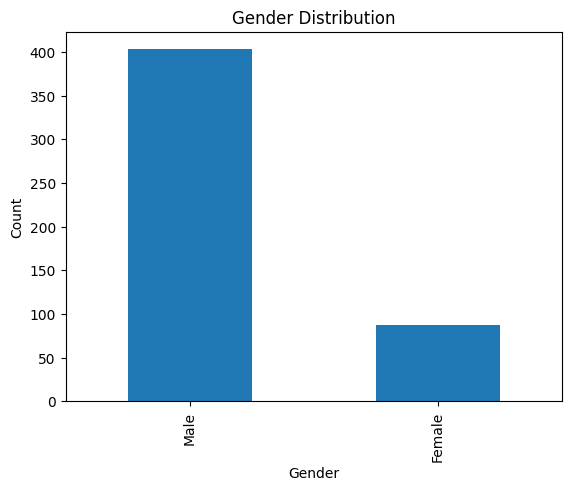

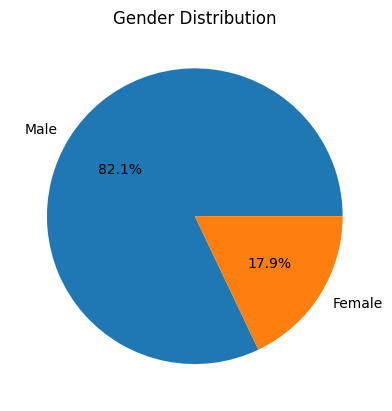

Married frequency table:
Married
Yes    325
No     166
Name: count, dtype: int64


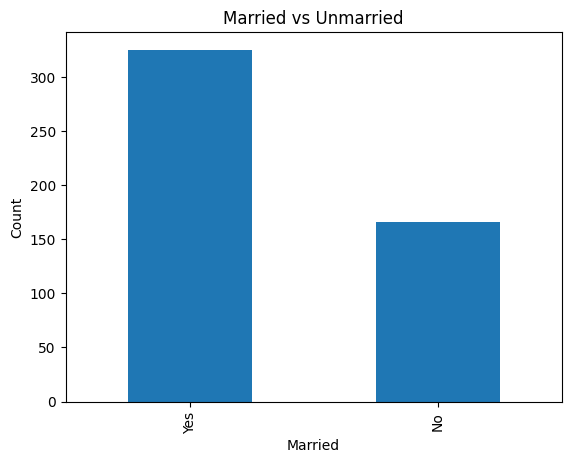

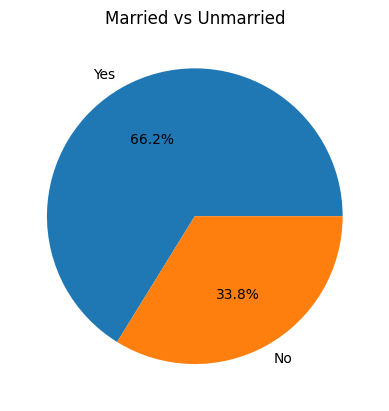

Education frequency table:
Education
Graduate        388
Not Graduate    103
Name: count, dtype: int64


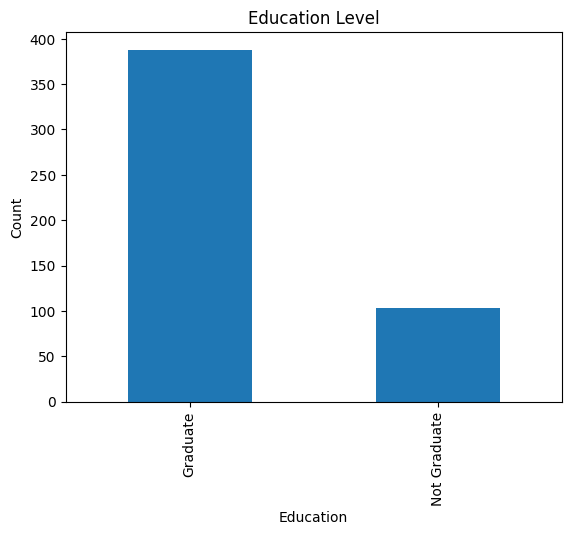

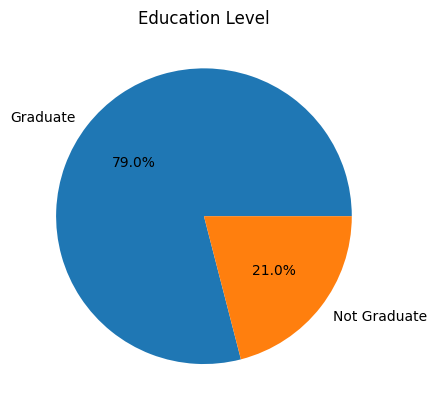

Self Employed frequency table:
Self_Employed
No     427
Yes     64
Name: count, dtype: int64


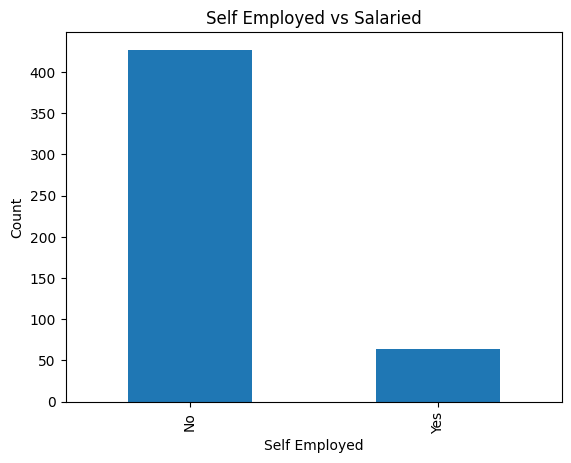

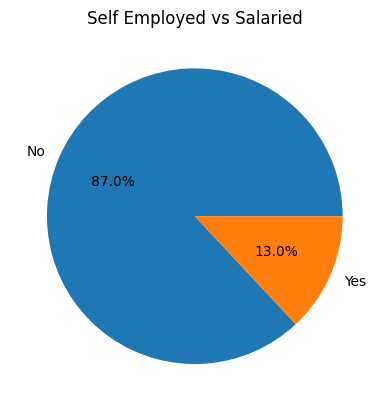

Property Area frequency table:
Property_Area
Semiurban    186
Urban        155
Rural        150
Name: count, dtype: int64


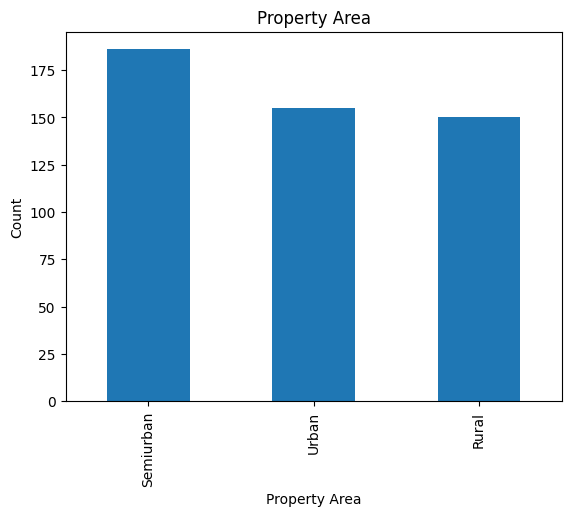

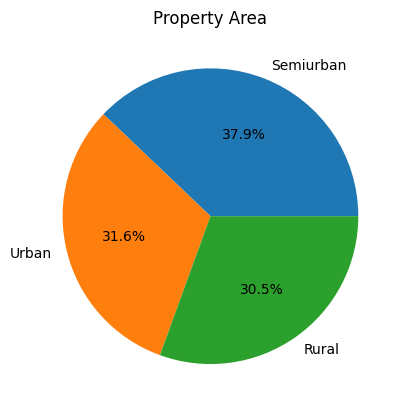

Loan approval frequency table:
Loan_Status
1    343
0    148
Name: count, dtype: int64


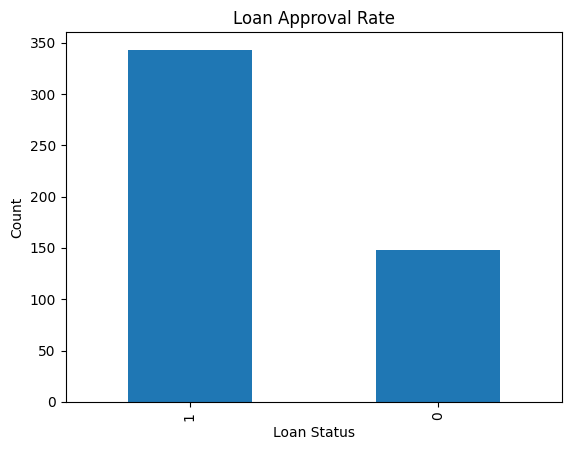

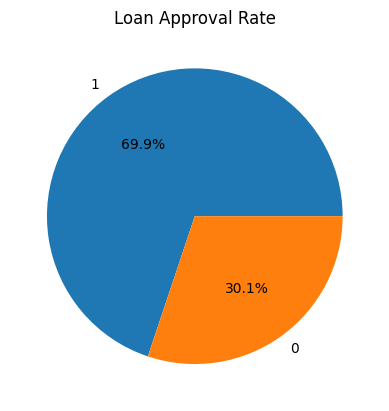

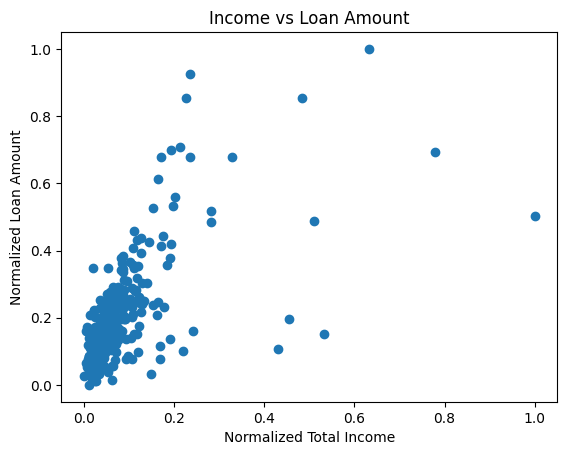

Correlation matrix:
                          ApplicantIncome_MinMax  CoapplicantIncome_MinMax  \
ApplicantIncome_MinMax                  1.000000                 -0.097735   
CoapplicantIncome_MinMax               -0.097735                  1.000000   
LoanAmount_MinMax                       0.582224                  0.191067   
Loan_Amount_Term_MinMax                -0.058443                 -0.070323   
TotalIncome_MinMax                      0.903754                  0.337674   
Loan_Status_Num                              NaN                       NaN   

                          LoanAmount_MinMax  Loan_Amount_Term_MinMax  \
ApplicantIncome_MinMax             0.582224                -0.058443   
CoapplicantIncome_MinMax           0.191067                -0.070323   
LoanAmount_MinMax                  1.000000                 0.038391   
Loan_Amount_Term_MinMax            0.038391                 1.000000   
TotalIncome_MinMax                 0.632843                -0.085522   
L

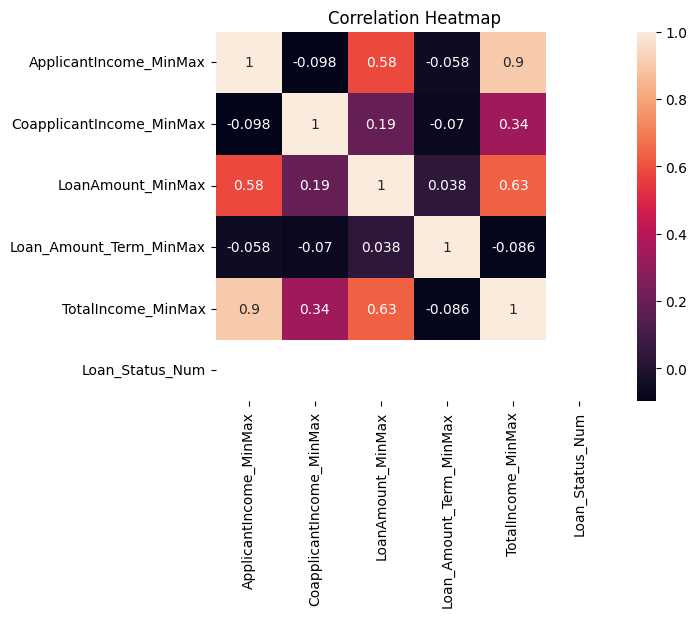

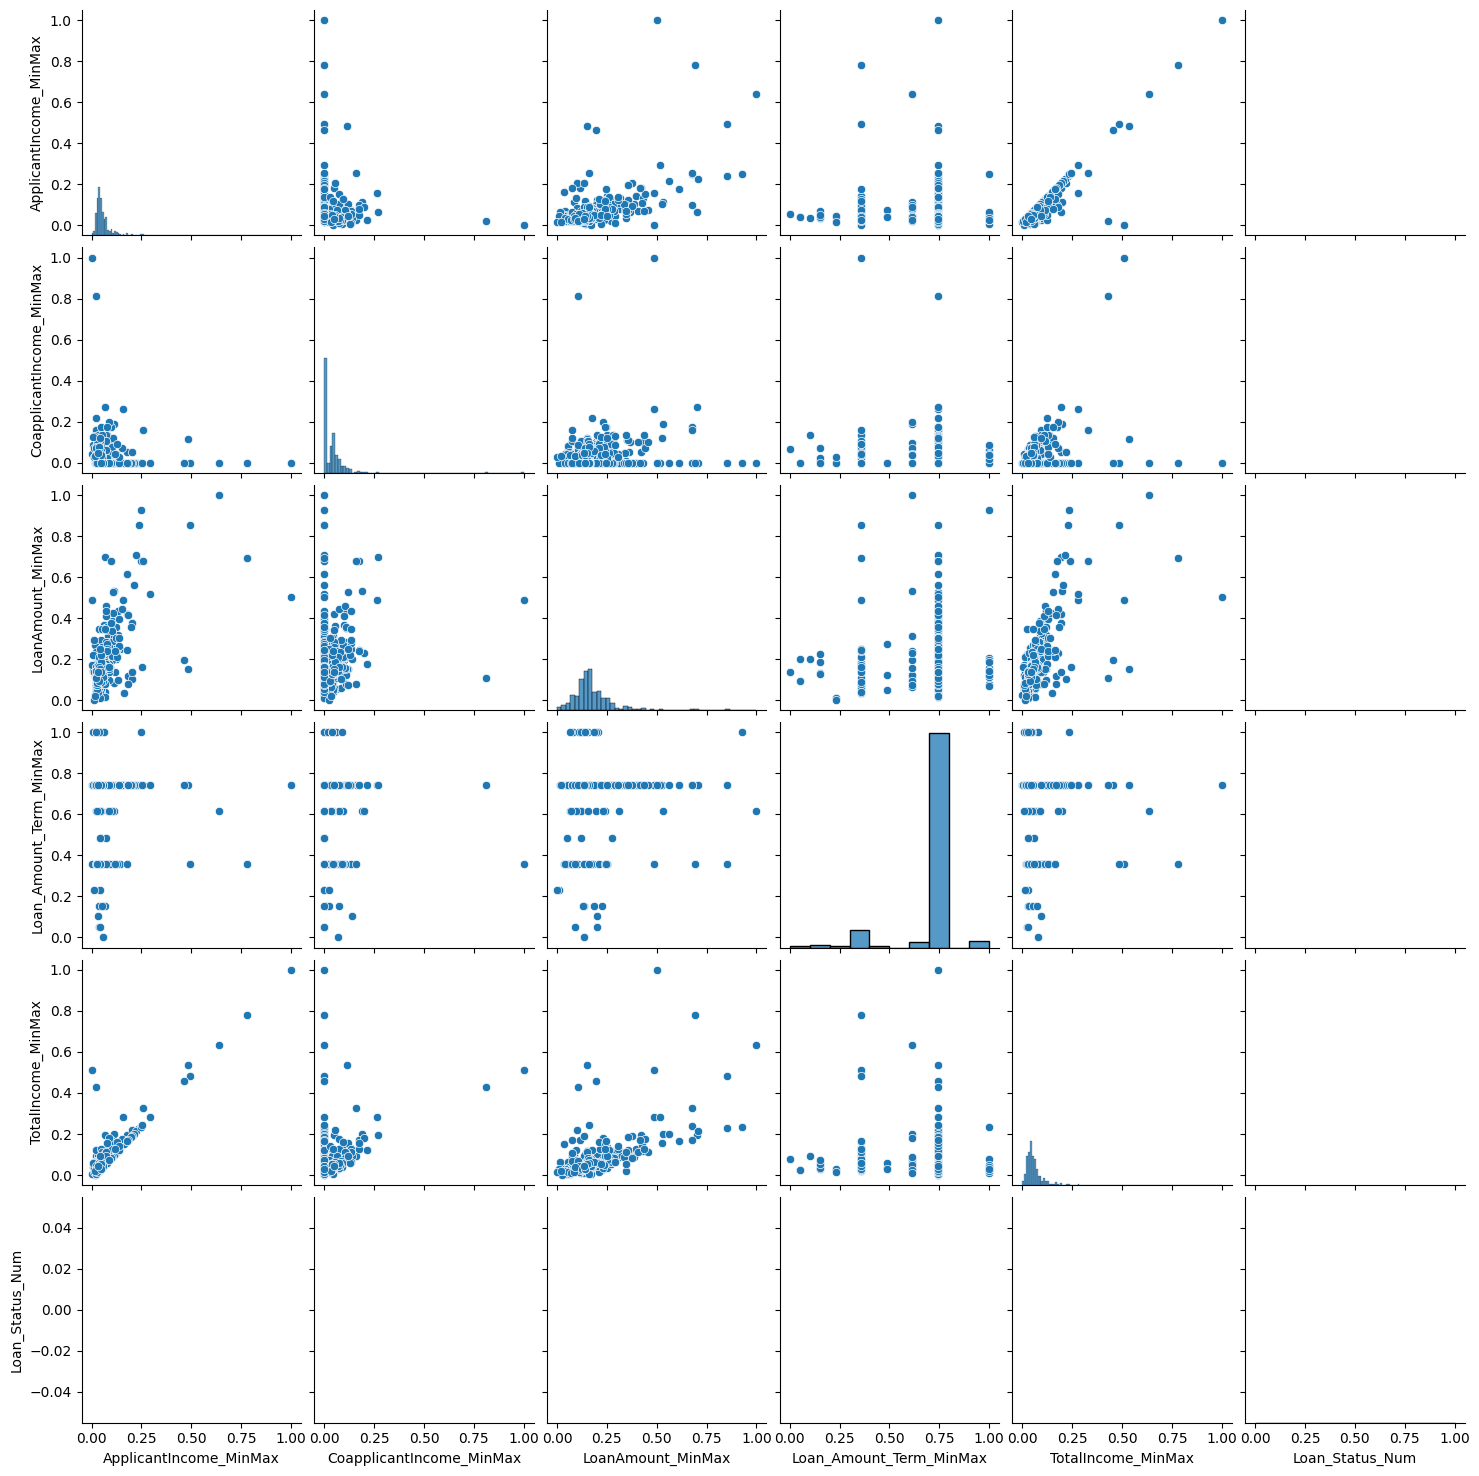

Final cleaned and normalized dataset:
   Unnamed: 0   Loan_ID  Gender Married Dependents     Education  \
0           0  LP002305  Female      No          0      Graduate   
1           1  LP001715    Male     Yes         3+  Not Graduate   
2           2  LP002086  Female     Yes          0      Graduate   
3           3  LP001136    Male     Yes          0  Not Graduate   
4           4  LP002529    Male     Yes          2      Graduate   

  Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  ...  \
0            No             4547                0.0       115.0  ...   
1           Yes             5703                0.0       130.0  ...   
2            No             4333             2451.0       110.0  ...   
3           Yes             4695                0.0        96.0  ...   
4            No             6700             1750.0       230.0  ...   

   CoapplicantIncome_MinMax  LoanAmount_MinMax Loan_Amount_Term_MinMax  \
0                  0.000000           0.143485

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# loading dataset
df = pd.read_excel("Loan Train Dataset (1).xlsx")
# first 5 rows
print(df.head())
# data types
print("Data types of all columns:")
print(df.dtypes)
# number of rows and columns
print("Shape of dataset:", df.shape)
print("Rows =", df.shape[0])
print("Columns =", df.shape[1])
# descriptive statistics
print("Descriptive statistics:")
print(df.describe())
print("Descriptive statistics including categorical columns:")
print(df.describe(include="all"))
# missing values
print("Missing values in each column:")
print(df.isnull().sum())
# making a copy for cleaning
df_clean = df.copy()
# handling missing values
df_clean["ApplicantIncome"] = df_clean["ApplicantIncome"].fillna(df_clean["ApplicantIncome"].mean())
df_clean["CoapplicantIncome"] = df_clean["CoapplicantIncome"].fillna(df_clean["CoapplicantIncome"].mean())
df_clean["LoanAmount"] = df_clean["LoanAmount"].fillna(df_clean["LoanAmount"].median())
df_clean["Loan_Amount_Term"] = df_clean["Loan_Amount_Term"].fillna(df_clean["Loan_Amount_Term"].median())
df_clean["Gender"] = df_clean["Gender"].fillna(df_clean["Gender"].mode()[0])
df_clean["Married"] = df_clean["Married"].fillna(df_clean["Married"].mode()[0])
df_clean["Dependents"] = df_clean["Dependents"].fillna(df_clean["Dependents"].mode()[0])
df_clean["Self_Employed"] = df_clean["Self_Employed"].fillna(df_clean["Self_Employed"].mode()[0])
df_clean["Credit_History"] = df_clean["Credit_History"].fillna(df_clean["Credit_History"].mode()[0])
print("Missing values after handling:")
print(df_clean.isnull().sum())
# duplicate rows
print("Duplicate rows before removing:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Duplicate rows after removing:", df_clean.duplicated().sum())
# checking inconsistent values
print("Unique values in categorical columns:")
categorical_cols = ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Loan_Status"]
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    print(col, ":", df_clean[col].unique())
# normalization
df_norm = df_clean.copy()
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
# min-max normalization
for col in num_cols:
    df_norm[col + "_MinMax"] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())
# z-score normalization
for col in num_cols:
    df_norm[col + "_Zscore"] = (df_norm[col] - df_norm[col].mean()) / df_norm[col].std()
print("Normalized values:")
print(df_norm[[col + "_MinMax" for col in num_cols] + [col + "_Zscore" for col in num_cols]].head())
# -------------------------------
# Gender Distribution
# -------------------------------
gender_counts = df_clean["Gender"].value_counts()
print("Gender frequency table:")
print(gender_counts)
gender_counts.plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()
gender_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()
# -------------------------------
# Married vs Unmarried
# -------------------------------
married_counts = df_clean["Married"].value_counts()
print("Married frequency table:")
print(married_counts)
married_counts.plot(kind="bar")
plt.title("Married vs Unmarried")
plt.xlabel("Married")
plt.ylabel("Count")
plt.show()
married_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Married vs Unmarried")
plt.ylabel("")
plt.show()
# -------------------------------
# Education Level
# -------------------------------
education_counts = df_clean["Education"].value_counts()
print("Education frequency table:")
print(education_counts)
education_counts.plot(kind="bar")
plt.title("Education Level")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()
education_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Education Level")
plt.ylabel("")
plt.show()
# -------------------------------
# Self Employed vs Salaried
# -------------------------------
self_counts = df_clean["Self_Employed"].value_counts()
print("Self Employed frequency table:")
print(self_counts)
self_counts.plot(kind="bar")
plt.title("Self Employed vs Salaried")
plt.xlabel("Self Employed")
plt.ylabel("Count")
plt.show()
self_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Self Employed vs Salaried")
plt.ylabel("")
plt.show()
# -------------------------------
# Property Area
# -------------------------------
property_counts = df_clean["Property_Area"].value_counts()
print("Property Area frequency table:")
print(property_counts)
property_counts.plot(kind="bar")
plt.title("Property Area")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.show()
property_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Property Area")
plt.ylabel("")
plt.show()
# -------------------------------
# Loan Approval Rate
# -------------------------------
loan_counts = df_clean["Loan_Status"].value_counts()
print("Loan approval frequency table:")
print(loan_counts)
loan_counts.plot(kind="bar")
plt.title("Loan Approval Rate")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()
loan_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Loan Approval Rate")
plt.ylabel("")
plt.show()
# -------------------------------
# Relationship Analysis
# -------------------------------
# total income
df_norm["TotalIncome"] = df_norm["ApplicantIncome"] + df_norm["CoapplicantIncome"]
# normalize total income
df_norm["TotalIncome_MinMax"] = (df_norm["TotalIncome"] - df_norm["TotalIncome"].min()) / (df_norm["TotalIncome"].max() - df_norm["TotalIncome"].min())
# loan status into numeric
df_norm["Loan_Status_Num"] = df_norm["Loan_Status"].map({"Y": 1, "N": 0})
# 1. Income vs Loan Amount
plt.scatter(df_norm["TotalIncome_MinMax"], df_norm["LoanAmount_MinMax"])
plt.title("Income vs Loan Amount")
plt.xlabel("Normalized Total Income")
plt.ylabel("Normalized Loan Amount")
plt.show()
# 2. Correlation Analysis
corr_cols = [
    "ApplicantIncome_MinMax",
    "CoapplicantIncome_MinMax",
    "LoanAmount_MinMax",
    "Loan_Amount_Term_MinMax",
    "TotalIncome_MinMax",
    "Loan_Status_Num"
]
corr_matrix = df_norm[corr_cols].corr()
print("Correlation matrix:")
print(corr_matrix)
# heatmap
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()
# pair plot
sns.pairplot(df_norm[corr_cols])
plt.show()

# final data preview
print("Final cleaned and normalized dataset:")
print(df_norm.head())